# Proyecto de regresión lineal - Medical Insurance Cost

En este notebook voy a resolver el ejercicio de regresión lineal con el dataset de costes médicos.  
La idea es hacerlo paso a paso, viendo un poco los datos, limpiándolos, preparando las variables y entrenando un modelo sencillo para predecir `charges`.


## 1. Importar librerías

Primero importo las librerías que voy a usar.  
Las dejo aquí juntas para tener el notebook más ordenado desde el principio.


In [23]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)


## 2. Cargar los datos

Cargo el dataset desde la URL del ejercicio para trabajar directamente sobre él.


In [24]:
url = "https://raw.githubusercontent.com/4GeeksAcademy/linear-regression-project-tutorial/main/medical_insurance_cost.csv"
total_data = pd.read_csv(url)
total_data.head()


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 3. Revisión rápida

Antes de entrenar nada, reviso el tamaño del dataset, los tipos de datos, los nulos y si hay duplicados.


In [25]:
total_data.shape

(1338, 7)

In [26]:
total_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [27]:
total_data.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [28]:
total_data.duplicated().sum()

np.int64(1)

## 4. Limpieza inicial

En este caso elimino los duplicados para quedarme con una versión limpia del dataset.


In [29]:
total_data = total_data.drop_duplicates().reset_index(drop=True)
total_data.shape


(1337, 7)

## 5. EDA rápido

Aquí hago una revisión visual sencilla para entender mejor cómo se comportan algunas variables.


In [30]:
total_data.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1337.0,39.222139,14.044333,18.0000,27.000,39.0000,51.00000,64.00000
bmi,1337.0,30.663452,6.100468,15.9600,26.290,30.4000,34.70000,53.13000
children,1337.0,1.095737,1.205571,0.0000,0.000,1.0000,2.00000,5.00000
charges,1337.0,13279.121487,12110.359656,1121.8739,4746.344,9386.1613,16657.71745,63770.42801


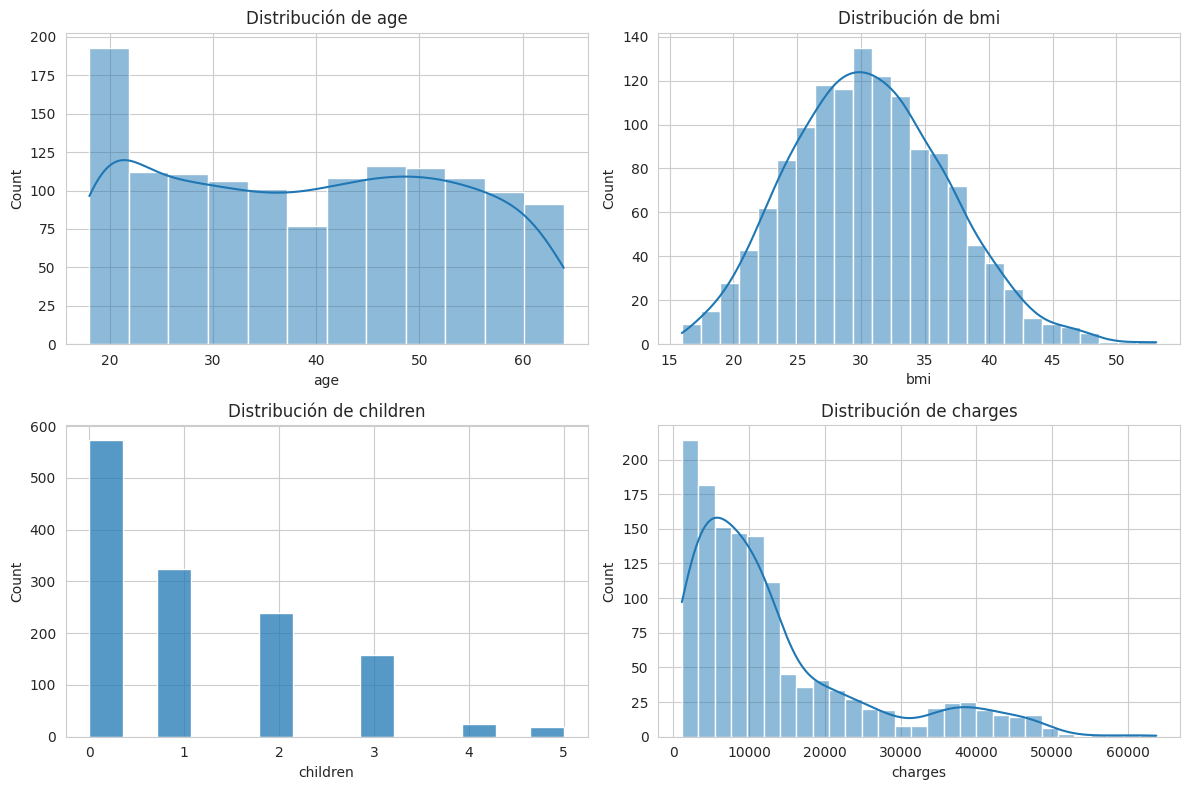

In [31]:
fig, axis = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(data=total_data, x="age", kde=True, ax=axis[0, 0])
axis[0, 0].set_title("Distribución de age")

sns.histplot(data=total_data, x="bmi", kde=True, ax=axis[0, 1])
axis[0, 1].set_title("Distribución de bmi")

sns.histplot(data=total_data, x="children", kde=False, ax=axis[1, 0])
axis[1, 0].set_title("Distribución de children")

sns.histplot(data=total_data, x="charges", kde=True, ax=axis[1, 1])
axis[1, 1].set_title("Distribución de charges")

plt.tight_layout()
plt.show()


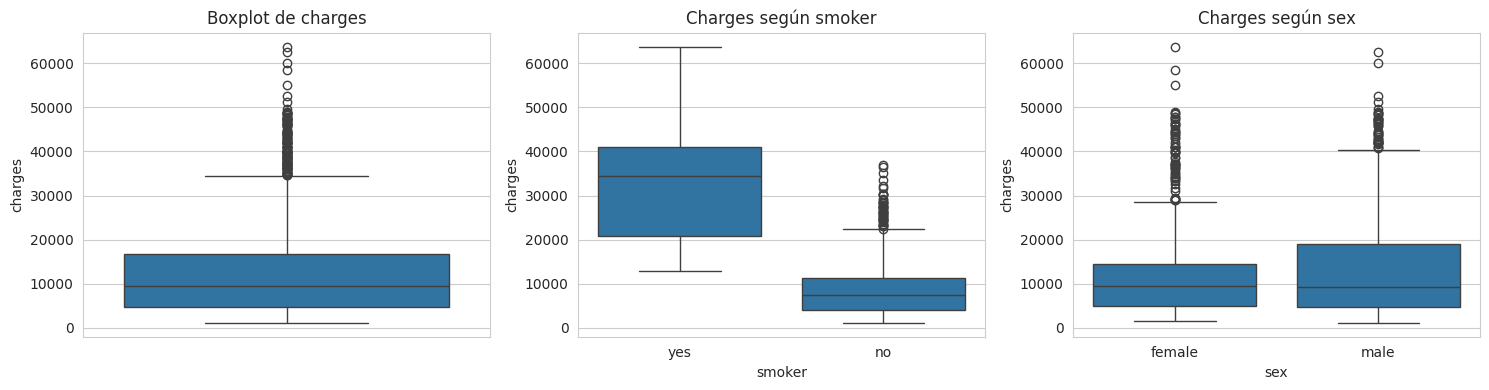

In [32]:
fig, axis = plt.subplots(1, 3, figsize=(15, 4))

sns.boxplot(data=total_data, y="charges", ax=axis[0])
axis[0].set_title("Boxplot de charges")

sns.boxplot(data=total_data, x="smoker", y="charges", ax=axis[1])
axis[1].set_title("Charges según smoker")

sns.boxplot(data=total_data, x="sex", y="charges", ax=axis[2])
axis[2].set_title("Charges según sex")

plt.tight_layout()
plt.show()


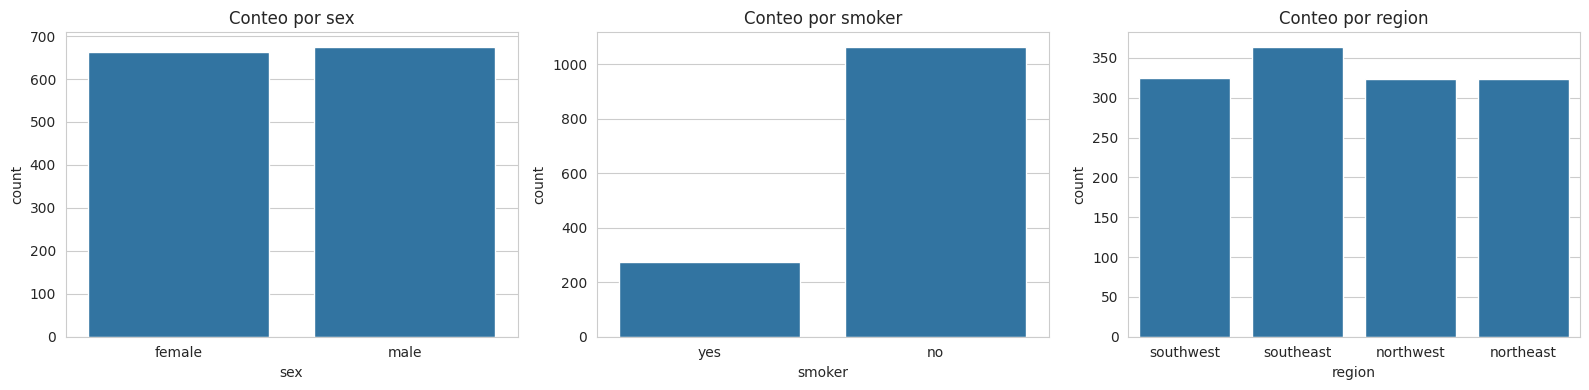

In [33]:
fig, axis = plt.subplots(1, 3, figsize=(16, 4))

sns.countplot(data=total_data, x="sex", ax=axis[0])
axis[0].set_title("Conteo por sex")

sns.countplot(data=total_data, x="smoker", ax=axis[1])
axis[1].set_title("Conteo por smoker")

sns.countplot(data=total_data, x="region", ax=axis[2])
axis[2].set_title("Conteo por region")

plt.tight_layout()
plt.show()


## 6. Pasar texto a números y escalar

Como la regresión lineal necesita variables numéricas, convierto las columnas categóricas a números.  
Después escalo las variables con Min-Max para dejarlas en una escala parecida.


In [34]:
total_data["sex_n"] = pd.factorize(total_data["sex"])[0]
total_data["smoker_n"] = pd.factorize(total_data["smoker"])[0]
total_data["region_n"] = pd.factorize(total_data["region"])[0]

num_variables = ["age", "bmi", "children", "sex_n", "smoker_n", "region_n"]

scaler = MinMaxScaler()
scal_features = scaler.fit_transform(total_data[num_variables])

total_data_scal = pd.DataFrame(scal_features, index=total_data.index, columns=num_variables)
total_data_scal["charges"] = total_data["charges"]

total_data_scal.head()


,age,bmi,children,sex_n,smoker_n,region_n,charges
0,0.021739,0.321227,0.0,0.0,0.0,0.000000,16884.92400
1,0.000000,0.479150,0.2,1.0,1.0,0.333333,1725.55230
2,0.217391,0.458434,0.6,1.0,1.0,0.333333,4449.46200
3,0.326087,0.181464,0.0,1.0,1.0,0.666667,21984.47061
4,0.304348,0.347592,0.0,1.0,1.0,0.666667,3866.85520


## 7. Relación con la variable objetivo

Aquí miro un poco qué variables parecen tener más relación con `charges`.


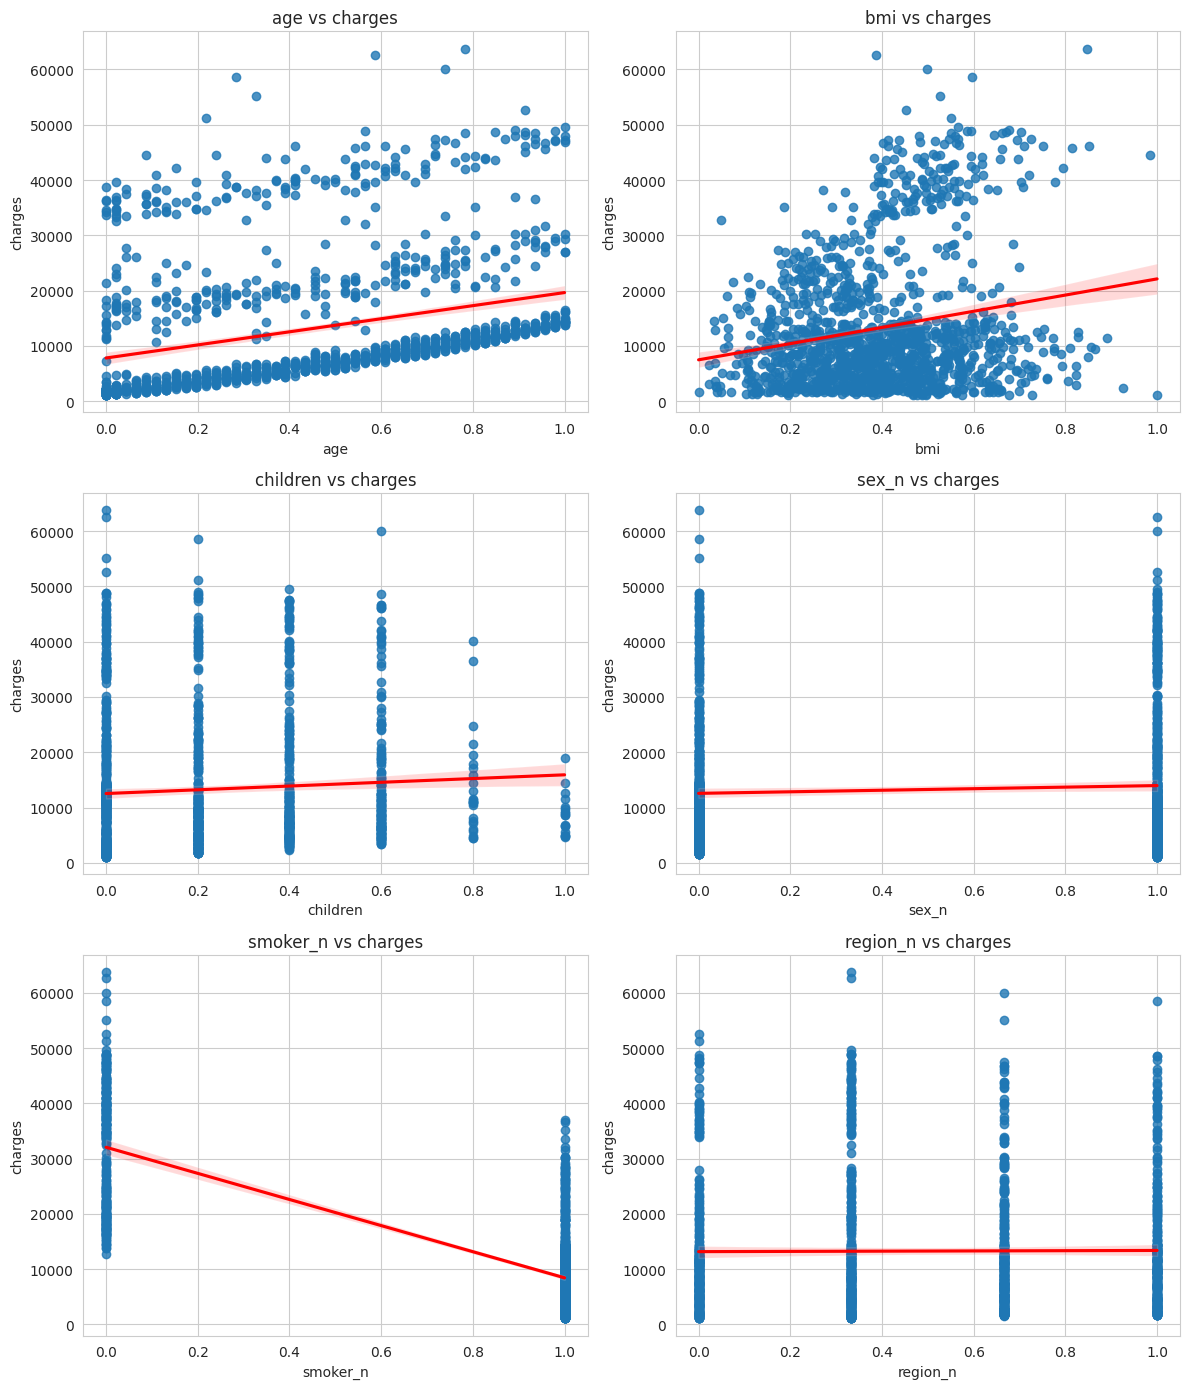

In [35]:
fig, axis = plt.subplots(3, 2, figsize=(12, 14))

sns.regplot(data=total_data_scal, x="age", y="charges", ax=axis[0, 0], line_kws={"color": "red"})
axis[0, 0].set_title("age vs charges")

sns.regplot(data=total_data_scal, x="bmi", y="charges", ax=axis[0, 1], line_kws={"color": "red"})
axis[0, 1].set_title("bmi vs charges")

sns.regplot(data=total_data_scal, x="children", y="charges", ax=axis[1, 0], line_kws={"color": "red"})
axis[1, 0].set_title("children vs charges")

sns.regplot(data=total_data_scal, x="sex_n", y="charges", ax=axis[1, 1], line_kws={"color": "red"})
axis[1, 1].set_title("sex_n vs charges")

sns.regplot(data=total_data_scal, x="smoker_n", y="charges", ax=axis[2, 0], line_kws={"color": "red"})
axis[2, 0].set_title("smoker_n vs charges")

sns.regplot(data=total_data_scal, x="region_n", y="charges", ax=axis[2, 1], line_kws={"color": "red"})
axis[2, 1].set_title("region_n vs charges")

plt.tight_layout()
plt.show()


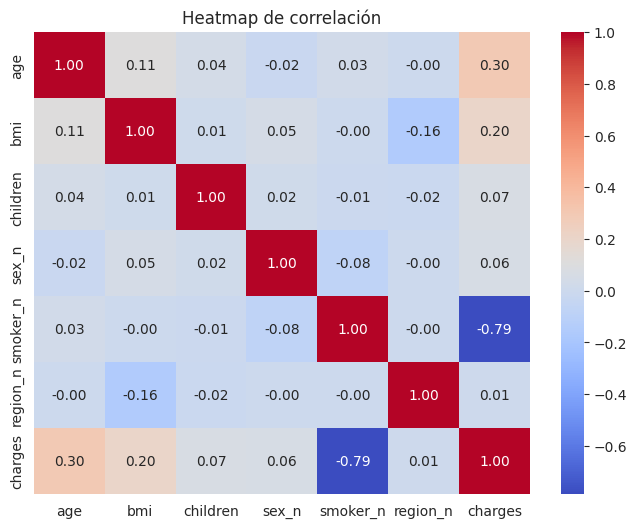

In [36]:
plt.figure(figsize=(8, 6))
sns.heatmap(total_data_scal.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Heatmap de correlación")
plt.show()


## 8. Selección de variables

Ahora separo X e y, hago train/test y me quedo con las variables que más relación tienen con la variable objetivo usando `SelectKBest`.


In [37]:
X = total_data_scal.drop("charges", axis=1)
y = total_data_scal["charges"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

selection_model = SelectKBest(score_func=f_regression, k=4)
selection_model.fit(X_train, y_train)

selected_columns = X_train.columns[selection_model.get_support()]
selected_columns


Index(['age', 'bmi', 'children', 'smoker_n'], dtype='str')

In [38]:
X_train_sel = pd.DataFrame(selection_model.transform(X_train), columns=selected_columns)
X_test_sel = pd.DataFrame(selection_model.transform(X_test), columns=selected_columns)

X_train_sel.head()


,age,bmi,children,smoker_n
0,0.108696,0.230024,0.0,1.0
1,0.065217,0.263250,0.4,1.0
2,0.739130,0.580172,0.4,1.0
3,0.978261,0.686306,0.0,1.0
4,0.630435,0.286252,0.4,1.0


## 9. Guardar datos procesados

Guardo una copia del train y del test por si luego quiero reutilizarlos sin repetir todo el preprocesado.


In [39]:
X_train_sel["charges"] = y_train.values
X_test_sel["charges"] = y_test.values

os.makedirs("data/processed", exist_ok=True)

X_train_sel.to_csv("data/processed/clean_train.csv", index=False)
X_test_sel.to_csv("data/processed/clean_test.csv", index=False)


In [40]:
train_data = X_train.copy()
train_data["y"] = y_train.values

test_data = X_test.copy()
test_data["y"] = y_test.values

train_data.head()


,age,bmi,children,sex_n,smoker_n,region_n,y
1113,0.108696,0.230024,0.0,1.0,1.0,1.000000,2396.09590
967,0.065217,0.263250,0.4,1.0,1.0,1.000000,3279.86855
598,0.739130,0.580172,0.4,0.0,1.0,0.666667,33471.97189
170,0.978261,0.686306,0.0,1.0,1.0,0.333333,13405.39030
275,0.630435,0.286252,0.4,0.0,1.0,1.000000,9715.84100


## 10. Modelo de regresión lineal

Ahora entreno una regresión lineal básica con las variables seleccionadas.


In [41]:
X_train = train_data.drop("y", axis=1)
y_train = train_data["y"]

X_test = test_data.drop("y", axis=1)
y_test = test_data["y"]

In [42]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print(f"Intercept: {model.intercept_}")
print(f"Coeficientes: {model.coef_}")


Intercept: 20758.584389905787
Coeficientes: [ 11443.14728148  11619.67819122   2670.60438271    -99.69539417
 -23052.15275173    712.87544245]


## 11. Predicciones y evaluación

Hago las predicciones sobre test y reviso las métricas principales.


In [43]:
y_pred = model.predict(X_test)
y_pred[:10]


array([ 8080.45018585,  5592.87111988, 14378.29865472, 31731.81954139,
        9158.3569444 , 13361.01426913, 30257.65525771,  1308.64735626,
       10849.42544516, 11375.54851897])

In [44]:
print(f"MSE: {mean_squared_error(y_test, y_pred)}")
print(f"R2 Score: {r2_score(y_test, y_pred)}")


MSE: 35493102.61165052
R2 Score: 0.8068466322629111


In [45]:
results = pd.DataFrame({
    "Real": y_test.values,
    "Predicción": y_pred
})

results.head(10)


,Real,Predicción
0,8688.85885,8080.450186
1,5708.86700,5592.871120
2,11436.73815,14378.298655
3,38746.35510,31731.819541
4,4463.20510,9158.356944
5,9304.70190,13361.014269
6,38511.62830,30257.655258
7,2150.46900,1308.647356
8,7345.72660,10849.425445
9,10264.44210,11375.548519


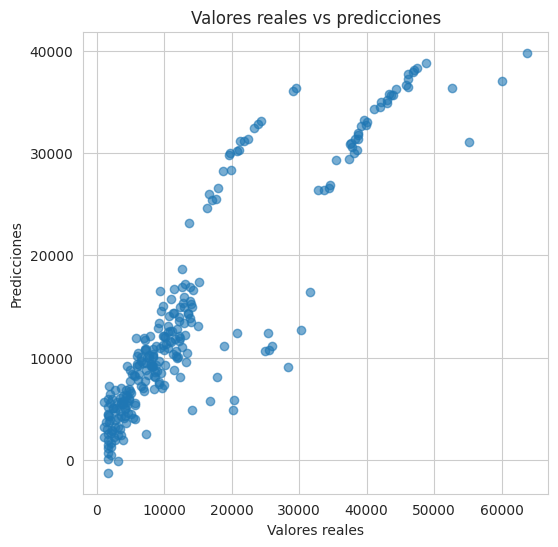

In [46]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title("Valores reales vs predicciones")
plt.show()


## 12. Guardar el modelo

Por último guardo el modelo por si luego quiero reutilizarlo sin volver a entrenarlo.


In [47]:
from pickle import dump

os.makedirs("models", exist_ok=True)
dump(model, open("models/linear_regression_medical_insurance.sav", "wb"))


## Conclusión

En este proyecto he cargado el dataset, he revisado los datos, he eliminado duplicados, he transformado las variables categóricas a numéricas, he escalado los datos, he seleccionado las variables más útiles y he entrenado un modelo de regresión lineal.

No es un análisis súper complejo, pero sí me sirve para entender bien el flujo completo de un problema de regresión y para montar un modelo sencillo y funcional.
